# SAIR — Module 5, Notebook 5: Inference and Text Generation

## Introduction

In Notebook 4 we trained a GPT model and saved checkpoints. Now we answer the next question: **how do you actually run it?**

Inference is not just calling `model(input)`. The way you decode the output determines everything — whether the text is repetitive or creative, safe or chaotic, coherent or random. This notebook teaches you every major decoding strategy, built from scratch on top of our custom GPT.

### The Generate Evolution

| Version | What's New |
|---------|------------|
| `generateV0` | Pure greedy — always picks the most probable next token |
| `generateV1` | + Temperature — control how random the sampling is |
| `generateV2` | + Top-k + Top-p (nucleus) — constrain the candidate pool |
| `generateV3` | + Beam search — explore multiple candidate sequences in parallel |

### What You Will Learn
1. How to load pretrained GPT-2 weights into our custom model
2. Why greedy decoding produces repetitive text
3. How temperature, top-k, and top-p control generation quality
4. How beam search finds better sequences by exploring multiple paths
5. How to wrap everything into a Gradio UI

In [5]:
import os, sys

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    if not os.path.exists('SAIR'):
        os.system('git clone https://github.com/silvaxxx1/SAIR.git')
    sys.path.insert(0, 'SAIR/5_GPT from scratch/')
    CACHE_DIR = 'SAIR/5_GPT from scratch/checkpoints'
else:
    sys.path.insert(0, '.')
    CACHE_DIR = 'checkpoints'

print(f"Colab: {IN_COLAB} | CACHE_DIR = {CACHE_DIR}")

Colab: False | CACHE_DIR = checkpoints


In [6]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

import torch
import torch.nn as nn
import torch.nn.functional as F

import tiktoken
from transformers import GPT2Model

from UTILS.model import GPTModel

device = "cuda" if torch.cuda.is_available() else "cpu"
tokenizer = tiktoken.get_encoding("gpt2")
print(f"Using device: {device}")

I0000 00:00:1776616049.964525  613629 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Using device: cuda


---
## Section 1 — Loading Pretrained Weights

In Notebook 4 we trained from scratch on a small dataset. For inference we want a model that actually knows English — so we load the official **GPT-2 Small (124M)** pretrained weights from HuggingFace into our custom architecture.

This is the same technique you'd use to load your own checkpoint:
1. Download the pretrained weights
2. Map them to our model's parameter names
3. Verify shape compatibility

> You can also load from your own Notebook 4 checkpoint by replacing `load_weights_from_hf` with `model.load_state_dict(torch.load('checkpoints/model_epoch_N.pt'))`

In [7]:
GPT_CONFIG_124M = {
    "vocab_size"     : 50257,
    "context_length" : 1024,
    "emb_dim"        : 768,
    "n_heads"        : 12,
    "n_layers"       : 12,
    "drop_rate"      : 0.0,
    "qkv_bias"       : True,
}

model_names = {
    "gpt2-small (124M)" : "openai-community/gpt2",
    "gpt2-medium (355M)": "openai-community/gpt2-medium",
    "gpt2-large (774M)" : "openai-community/gpt2-large",
    "gpt2-xl (1558M)"   : "openai-community/gpt2-xl",
}

print("Downloading GPT-2 Small weights from HuggingFace...")
gpt_hf = GPT2Model.from_pretrained(model_names["gpt2-small (124M)"], cache_dir=CACHE_DIR)
gpt_hf.eval()
print("Done.")

Done.


In [8]:
import numpy as np

def assign_check(left, right):
    """Copy right into left, raising an error if shapes don't match."""
    if left.shape != right.shape:
        raise ValueError(f"Shape mismatch: {left.shape} vs {right.shape}")
    return nn.Parameter(right.clone().detach())


def load_weights_from_hf(gpt, gpt_hf):
    """Map HuggingFace GPT-2 weights to our custom GPTModel."""
    d = gpt_hf.state_dict()

    gpt.pos_emb.weight = assign_check(gpt.pos_emb.weight, d["wpe.weight"])
    gpt.tok_emb.weight = assign_check(gpt.tok_emb.weight, d["wte.weight"])

    for b in range(GPT_CONFIG_124M["n_layers"]):
        # Split fused QKV weight into separate Q, K, V
        q_w, k_w, v_w = np.split(d[f"h.{b}.attn.c_attn.weight"], 3, axis=-1)
        gpt.trf_blocks[b].att.W_query.weight = assign_check(gpt.trf_blocks[b].att.W_query.weight, q_w.T)
        gpt.trf_blocks[b].att.W_key.weight   = assign_check(gpt.trf_blocks[b].att.W_key.weight,   k_w.T)
        gpt.trf_blocks[b].att.W_value.weight = assign_check(gpt.trf_blocks[b].att.W_value.weight, v_w.T)

        q_b, k_b, v_b = np.split(d[f"h.{b}.attn.c_attn.bias"], 3, axis=-1)
        gpt.trf_blocks[b].att.W_query.bias = assign_check(gpt.trf_blocks[b].att.W_query.bias, q_b)
        gpt.trf_blocks[b].att.W_key.bias   = assign_check(gpt.trf_blocks[b].att.W_key.bias,   k_b)
        gpt.trf_blocks[b].att.W_value.bias = assign_check(gpt.trf_blocks[b].att.W_value.bias, v_b)

        gpt.trf_blocks[b].att.out_proj.weight = assign_check(
            gpt.trf_blocks[b].att.out_proj.weight, d[f"h.{b}.attn.c_proj.weight"].T)
        gpt.trf_blocks[b].att.out_proj.bias   = assign_check(
            gpt.trf_blocks[b].att.out_proj.bias,   d[f"h.{b}.attn.c_proj.bias"])

        gpt.trf_blocks[b].ff.layers[0].weight = assign_check(
            gpt.trf_blocks[b].ff.layers[0].weight, d[f"h.{b}.mlp.c_fc.weight"].T)
        gpt.trf_blocks[b].ff.layers[0].bias   = assign_check(
            gpt.trf_blocks[b].ff.layers[0].bias,   d[f"h.{b}.mlp.c_fc.bias"])
        gpt.trf_blocks[b].ff.layers[2].weight = assign_check(
            gpt.trf_blocks[b].ff.layers[2].weight, d[f"h.{b}.mlp.c_proj.weight"].T)
        gpt.trf_blocks[b].ff.layers[2].bias   = assign_check(
            gpt.trf_blocks[b].ff.layers[2].bias,   d[f"h.{b}.mlp.c_proj.bias"])

        gpt.trf_blocks[b].norm1.scale = assign_check(gpt.trf_blocks[b].norm1.scale, d[f"h.{b}.ln_1.weight"])
        gpt.trf_blocks[b].norm1.shift = assign_check(gpt.trf_blocks[b].norm1.shift, d[f"h.{b}.ln_1.bias"])
        gpt.trf_blocks[b].norm2.scale = assign_check(gpt.trf_blocks[b].norm2.scale, d[f"h.{b}.ln_2.weight"])
        gpt.trf_blocks[b].norm2.shift = assign_check(gpt.trf_blocks[b].norm2.shift, d[f"h.{b}.ln_2.bias"])

    gpt.final_norm.scale = assign_check(gpt.final_norm.scale, d["ln_f.weight"])
    gpt.final_norm.shift = assign_check(gpt.final_norm.shift, d["ln_f.bias"])
    gpt.out_head.weight  = assign_check(gpt.out_head.weight,  d["wte.weight"])


# Build our model and load the pretrained weights
model = GPTModel(GPT_CONFIG_124M)
load_weights_from_hf(model, gpt_hf)
model.to(device)
model.eval()
print("Pretrained GPT-2 weights loaded into our custom model.")

Pretrained GPT-2 weights loaded into our custom model.


---
## Section 2 — generateV0: Pure Greedy Decoding

The simplest possible inference strategy: at each step, pick the **single most probable next token**.

```
logits = model(context)          # forward pass
next_token = argmax(logits[-1])  # always pick the top token
```

**The problem with greedy:** it is completely deterministic. Run it 10 times on the same prompt — you get the same output every time. It also tends to produce **repetitive, looping text** because the most probable next token is often the same word that came before.

> Greedy is great for verifying your model works. It's not suitable for real text generation.

In [9]:
def generateV0(model, prompt, max_new_tokens, context_size, tokenizer):
    """Pure greedy decoding — always picks the highest-probability next token."""
    idx = torch.tensor(tokenizer.encode(prompt), dtype=torch.long).unsqueeze(0).to(device)

    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]
        with torch.no_grad():
            logits = model(idx_cond)[:, -1, :]      # forward pass, take last token logits
        idx_next = torch.argmax(logits, dim=-1, keepdim=True)  # pick top token
        idx = torch.cat([idx, idx_next], dim=1)

    return tokenizer.decode(idx.squeeze(0).tolist())

In [10]:
prompt = "I have a dream"

# Run it multiple times — output is identical every time
for i in range(3):
    out = generateV0(model, prompt, max_new_tokens=10,
                     context_size=GPT_CONFIG_124M["context_length"], tokenizer=tokenizer)
    print(f"Run {i+1}: {out}")

Run 1: I have a dream of being a doctor. I have a dream of
Run 2: I have a dream of being a doctor. I have a dream of
Run 3: I have a dream of being a doctor. I have a dream of


/tmp/ipykernel_613629/3645519816.py:34: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


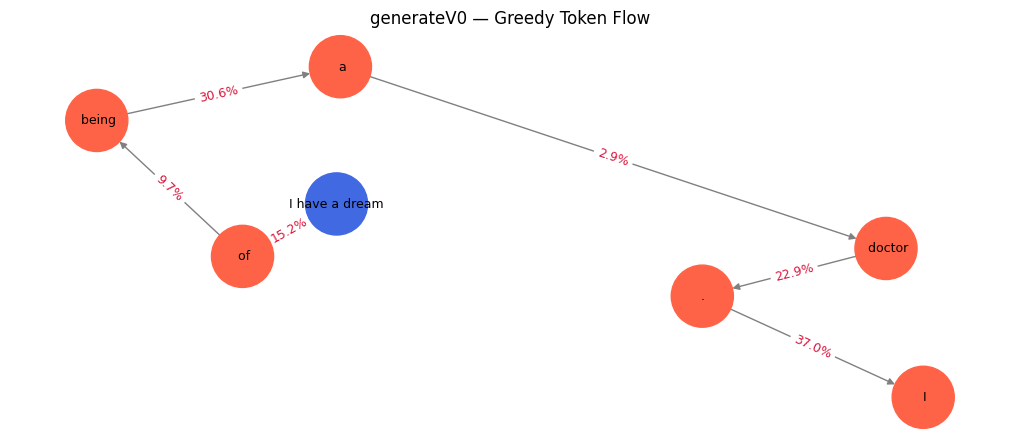

In [11]:
def visualize_token_flow(model, prompt, steps, tokenizer, title="Token Flow", temperature=0.0):                                                             
      idx = torch.tensor(tokenizer.encode(prompt), dtype=torch.long).unsqueeze(0).to(device)                                                                  
                                                                                                                                                              
      G = nx.DiGraph()                                                                                                                                        
      prev = prompt                                                                                                                                           
      G.add_node(prev, color="royalblue")                   

      for _ in range(steps):                                                                                                                                  
          with torch.no_grad():
              logits = model(idx)[:, -1, :]                                                                                                                   
          probs = F.softmax(logits, dim=-1)                 

          if temperature == 0.0:
              next_id = torch.argmax(probs, dim=-1)
          else:                                                                                                                                               
              next_id = torch.multinomial(F.softmax(logits / temperature, dim=-1), num_samples=1).squeeze(-1)
                                                                                                                                                              
          prob_val = probs[0, next_id.item()].item()        
          new_token = tokenizer.decode([next_id.item()])                                                                                                      
                                                            
          G.add_node(new_token, color="tomato")                                                                                                               
          G.add_edge(prev, new_token, weight=prob_val)
          prev = new_token                                                                                                                                    
          idx = torch.cat([idx, next_id.unsqueeze(0)], dim=1)

      plt.figure(figsize=(10, 4))                                                                                                                             
      colors = [G.nodes[n]["color"] for n in G.nodes]
      pos = nx.spring_layout(G, seed=42)                                                                                                                      
      nx.draw(G, pos, with_labels=True, node_color=colors,  
              edge_color="gray", font_size=9, node_size=2000)
      edge_labels = {(u, v): f"{d['weight']*100:.1f}%" for u, v, d in G.edges(data=True)}                                                                     
      nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color="crimson", font_size=9)
      plt.title(title)                                                                                                                                        
      plt.tight_layout()                                    
      plt.show()


visualize_token_flow(model, "I have a dream", steps=6, tokenizer=tokenizer,
                     title="generateV0 — Greedy Token Flow")

## Section 3 — generateV1: + Temperature

To move beyond greedy decoding, introduce temperature: a parameter that controls how concentrated or spread out token probabilities become.

logits = logits / temperature
probs  = softmax(logits)
token  = sample(probs)

| Temperature | Effect |
|-------------|--------|
| 0 (special case) | Greedy argmax |
| 0.1–0.5 | Very focused |
| 0.7–1.0 | Balanced |
| >1.0 | More random / diverse |

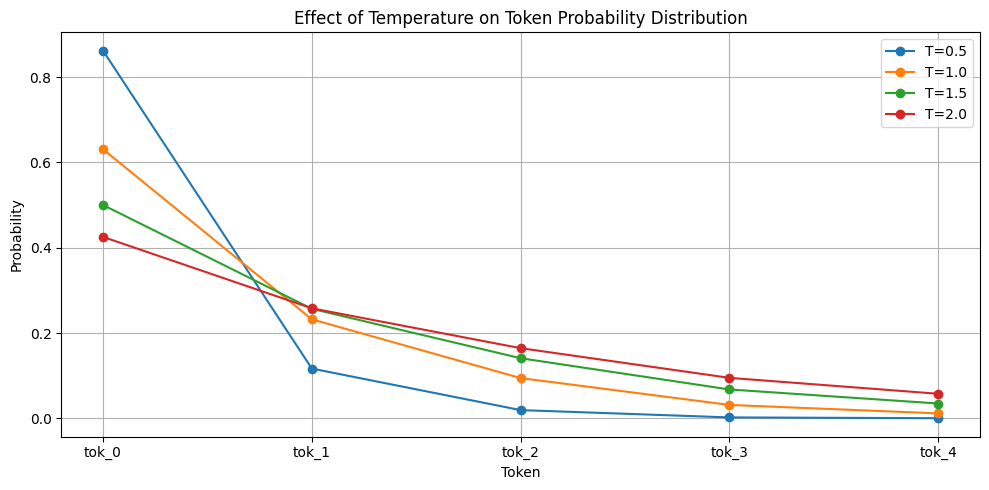

In [12]:
# Visualize what temperature does to the probability distribution
sample_logits = torch.tensor([2.0, 1.0, 0.1, -1.0, -2.0])
temperatures  = [0.5, 1.0, 1.5, 2.0]
token_labels  = [f"tok_{i}" for i in range(len(sample_logits))]

plt.figure(figsize=(10, 5))
for temp in temperatures:
    probs = F.softmax(sample_logits / temp, dim=-1).numpy()
    plt.plot(probs, marker="o", label=f"T={temp}")

plt.xticks(range(len(token_labels)), token_labels)
plt.title("Effect of Temperature on Token Probability Distribution")
plt.xlabel("Token")
plt.ylabel("Probability")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [13]:
def generateV1(model, prompt, max_new_tokens, context_size, tokenizer,
               temperature=1.0):                                      # [V1] temperature param
    """V0 + temperature scaling for controlled randomness."""
    idx = torch.tensor(tokenizer.encode(prompt), dtype=torch.long).unsqueeze(0).to(device)

    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]
        with torch.no_grad():
            logits = model(idx_cond)[:, -1, :]

        if temperature == 0.0:                                        # [V1] greedy fallback
            idx_next = torch.argmax(logits, dim=-1, keepdim=True)
        else:
            logits   = logits / temperature                           # [V1] scale logits
            probs    = F.softmax(logits, dim=-1)                      # [V1] to probabilities
            idx_next = torch.multinomial(probs, num_samples=1)        # [V1] sample

        idx = torch.cat([idx, idx_next], dim=1)

    return tokenizer.decode(idx.squeeze(0).tolist())

````markdown id="f7yqzx"
## `idx_next = torch.multinomial(probs, num_samples=1)`

This line selects the **next token by sampling from the probability distribution** instead of always choosing the highest-probability token.

After:

```python
probs = F.softmax(logits, dim=-1)
````

the model output might look like:

| Token | Probability |
| ----- | ----------- |
| A     | 0.70        |
| B     | 0.20        |
| C     | 0.10        |

Then:

```python
idx_next = torch.multinomial(probs, num_samples=1)
```

randomly picks **one token index** using those weights:

* A is chosen most of the time
* B sometimes
* C rarely

Unlike greedy decoding:

```python
torch.argmax(probs, dim=-1)
```

which would always choose `A`.

`num_samples=1` means choose **one next token**, which is then appended to the sequence.

**Mental model:** `argmax` = choose best token, `multinomial` = roll weighted dice.

```
```


In [14]:
prompt = "I have a dream"
for temp in [0.0, 0.5, 1.0, 1.5]:
    out = generateV1(model, prompt, max_new_tokens=15,
                     context_size=GPT_CONFIG_124M["context_length"],
                     tokenizer=tokenizer, temperature=temp)
    print(f"T={temp:.1f}: {out}")

T=0.0: I have a dream of being a doctor. I have a dream of being a doctor. I
T=0.5: I have a dream of being the next Steve Jobs. I have a dream of being the next
T=1.0: I have a dream that is maybe even better than that undertaken.

What would you tell
T=1.5: I have a dreamRA ETH13 YPrem Suspicious link because it mentions pointing you Ruler:


/tmp/ipykernel_613629/3645519816.py:34: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


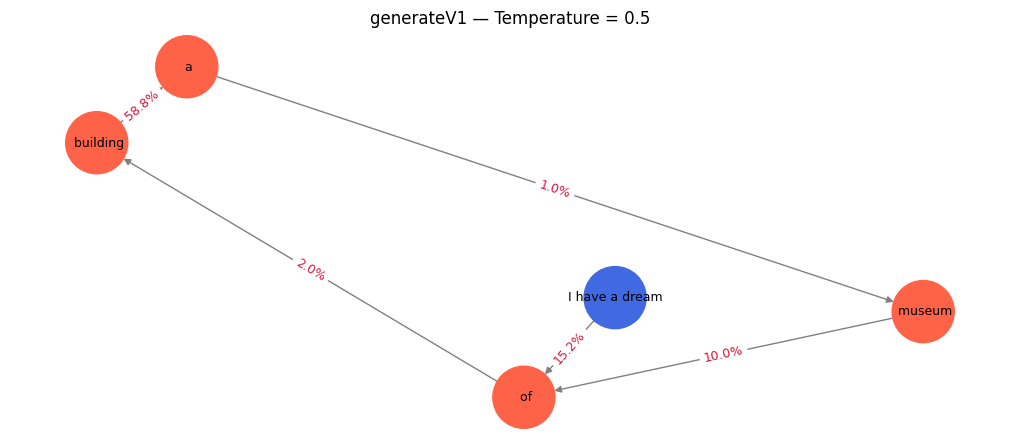

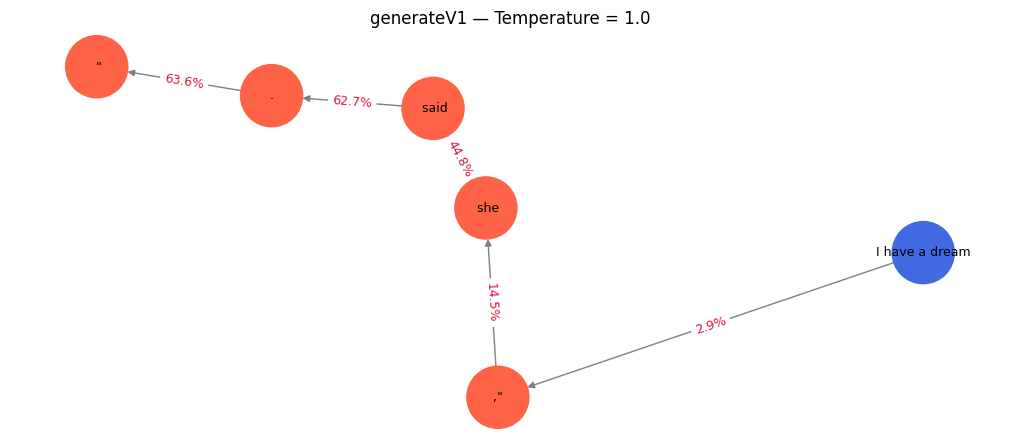

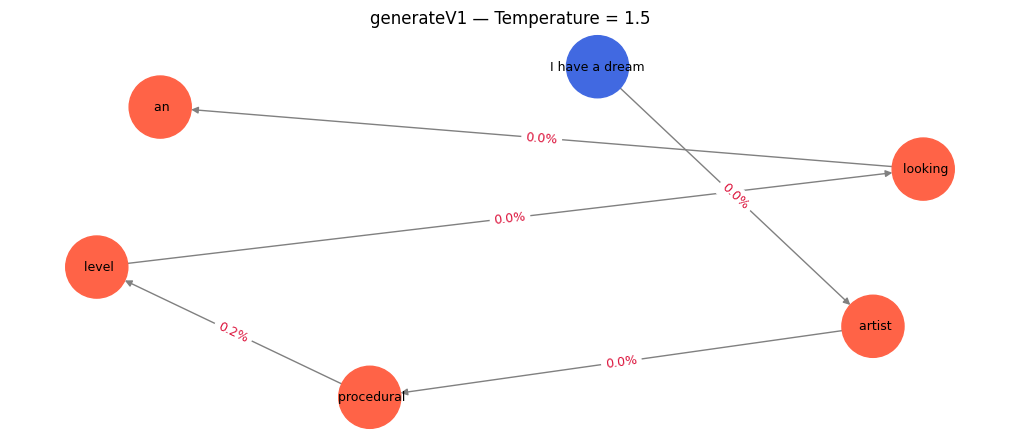

In [15]:
for temp in [0.5, 1.0, 1.5]:                                                                                                                                
      visualize_token_flow(                                 
          model, "I have a dream", steps=5, tokenizer=tokenizer,
          title=f"generateV1 — Temperature = {temp}",                                                                                                         
          temperature=temp
      ) 

---
## Section 4 — generateV2: + Top-k and Top-p (Nucleus) Sampling

Temperature alone can still sample very unlikely tokens (e.g. nonsense words). We add two filters that **constrain the candidate pool** before sampling.

### Top-k Sampling
Keep only the `k` most probable tokens. Set everything else to `-inf` before softmax.

```
k=50: sample from the 50 most likely tokens only
```

### Top-p (Nucleus) Sampling
Instead of a fixed k, keep the **smallest set of tokens whose cumulative probability ≥ p**.

```
p=0.9: keep tokens that together account for 90% of the probability mass
```

Top-p is more adaptive than top-k: when the model is confident, it considers fewer tokens; when uncertain, it considers more.

New lines vs V1 marked `# [V2]`.

In [16]:
def apply_top_k(logits, k):
    """Zero out all logits except the top-k."""
    threshold = torch.topk(logits, k).values[..., -1, None]
    return logits.masked_fill(logits < threshold, float("-inf"))


def apply_top_p(logits, p):
    """Zero out logits outside the nucleus (smallest set summing to >= p)."""
    probs = F.softmax(logits, dim=-1)
    sorted_probs, sorted_idx = torch.sort(probs, descending=True)
    cumulative = torch.cumsum(sorted_probs, dim=-1)
    # Remove tokens once cumulative probability exceeds p
    sorted_probs[cumulative > p] = 0.0
    # Scatter back to original order
    filtered = torch.zeros_like(logits)
    filtered.scatter_(dim=-1, index=sorted_idx, src=sorted_probs)
    return filtered


# Quick demo: top-k on mock logits
mock = torch.tensor([[3.0, 1.0, 0.1, 0.5, 1.5, 2.5, 0.2, 0.8, 1.8, 2.0]])
print("Original logits:        ", mock.squeeze().tolist())
print("After top-k (k=3):      ", apply_top_k(mock.clone(), k=3).squeeze().tolist())
print("After top-p (p=0.9):    ", apply_top_p(mock.clone(), p=0.9).squeeze().tolist())

Original logits:         [3.0, 1.0, 0.10000000149011612, 0.5, 1.5, 2.5, 0.20000000298023224, 0.800000011920929, 1.7999999523162842, 2.0]
After top-k (k=3):       [3.0, -inf, -inf, -inf, -inf, 2.5, -inf, -inf, -inf, 2.0]
After top-p (p=0.9):     [0.3398134410381317, 0.045988745987415314, 0.0, 0.0, 0.0758226290345192, 0.2061072736978531, 0.0, 0.0, 0.10234983265399933, 0.1250103861093521]


In [17]:
def generateV2(model, prompt, max_new_tokens, context_size, tokenizer,
               temperature=1.0, top_k=None, top_p=None, eos=None):  # [V2] new params
    """V1 + top-k filtering + top-p (nucleus) sampling + EOS support."""
    idx = torch.tensor(tokenizer.encode(prompt), dtype=torch.long).unsqueeze(0).to(device)

    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]
        with torch.no_grad():
            logits = model(idx_cond)[:, -1, :]

        if top_k is not None:                                         # [V2] top-k filter
            logits = apply_top_k(logits, top_k)

        if top_p is not None:                                         # [V2] top-p filter
            logits = apply_top_p(logits, top_p)

        if temperature == 0.0:
            idx_next = torch.argmax(logits, dim=-1, keepdim=True)
        else:
            logits   = logits / temperature
            probs    = F.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)

        if eos is not None and idx_next.item() == eos:                # [V2] EOS check
            break

        idx = torch.cat([idx, idx_next], dim=1)

    return tokenizer.decode(idx.squeeze(0).tolist())

In [18]:
prompt = "I have a dream"

print("=== Greedy (T=0) ===")
print(generateV2(model, prompt, 20, GPT_CONFIG_124M["context_length"], tokenizer, temperature=0.0))

print("\n=== Temperature only (T=0.8) ===")
print(generateV2(model, prompt, 20, GPT_CONFIG_124M["context_length"], tokenizer, temperature=0.8))

print("\n=== Temperature + Top-k (T=0.8, k=50) ===")
print(generateV2(model, prompt, 20, GPT_CONFIG_124M["context_length"], tokenizer, temperature=0.8, top_k=50))

print("\n=== Temperature + Top-p (T=0.8, p=0.9) ===")
print(generateV2(model, prompt, 20, GPT_CONFIG_124M["context_length"], tokenizer, temperature=0.8, top_p=0.9))

print("\n=== Top-k + Top-p combined (T=0.8, k=50, p=0.9) ===")
print(generateV2(model, prompt, 20, GPT_CONFIG_124M["context_length"], tokenizer,
                 temperature=0.8, top_k=50, top_p=0.9))

=== Greedy (T=0) ===
I have a dream of being a doctor. I have a dream of being a doctor. I have a dream of being

=== Temperature only (T=0.8) ===
I have a dream to build a home where I can go to college and be a productive citizen," he said.


=== Temperature + Top-k (T=0.8, k=50) ===
I have a dream. I want to marry someone who can't be my husband, but doesn't have to be my

=== Temperature + Top-p (T=0.8, p=0.9) ===
I have a dream Natoaker exposures Jade Investments splendidLost orcsmess Tayphies Arknt glyphosateī precedent assaultstal race Stein

=== Top-k + Top-p combined (T=0.8, k=50, p=0.9) ===
I have a dream Parliamentary� swords withhelditage snowball DOLER Mbps SystemsClick龍� Caribbeanzo CrossRef families MoinesDiscuss');iet


## Section 5 — generateV3: Beam Search

Greedy decoding keeps only **one path** and commits immediately at each token. If it makes a poor local choice early, it cannot recover.

Beam search keeps **B parallel candidate sequences** ("beams"). At every step:

1. Expand each beam with likely next tokens
2. Score all new candidates
3. Keep only the best `B` total sequences
4. Repeat until completion

---

## Greedy vs Beam Search

### Greedy (`B = 1`)

```text id="k0ff7j"
"I have" 
   └── "a"
        └── "dream"
             └── ...
```

One path only.

### Beam Search (`B = 3`)

```text id="c1r4o2"
"I have"
 ├── "a"
 ├── "to"
 └── "the"
```

Keeps several plausible futures alive.

![Image](https://images.openai.com/static-rsc-4/a4Be-Sk1ZrGkqAm7XQAbSmR0zNZHTEUxEGr3pFSY8H7ZNiis29gvYlZPSSbGsdPolkhuu1Js_07XEOJ94meg7u1ognf_5ToTZm9pnIQvAoW9zebH30G6e7Du7mGuFNT1yAnk4mgkz0ttRKXJNtDhXLq427NT9Y_3q7wwv_BQUqb-Doe_m2G5UQdaXkwffVnl?purpose=fullsize)

![Image](https://images.openai.com/static-rsc-4/k3UQVZSKIYn0czG8IMOuG7HL4JvL1-ZlX-7J5zaDwIcPWu0IsLjNVeCtioMTlH1INrPAQzvuKIgTYCxWToLiUVTO8vpvHnTvqJJeiJIY67va_AorSTwXVh3RN618S4Q5jNd62XLlZ7Y8hRwqZRCWdHScD4JHShYM1HL7bvF7zod4dPXexymbZfkQeZHXjkoY?purpose=fullsize)

---

## Example with B = 3

### Step 0

```text id="g5qg1w"
["I have"]
```

### Step 1 — Expand top candidates

```text id="6pknuv"
["I have a",
 "I have to",
 "I have the"]
```

### Step 2 — Expand all 3 beams

Each beam generates 3 new options:

```text id="91j6e9"
"I have a"   -> a dream, a plan, a feeling
"I have to"  -> to go, to say, to be
"I have the" -> the time, the power, the answer
```

Total:

```text id="6y7gvk"
9 candidates
```

Then keep best 3 globally:

```text id="h5nn80"
["I have a dream",
 "I have the power",
 "I have to be"]
```

---

## Why It Often Beats Greedy

Greedy may choose the highest next token now, but that path can become weak later.

Beam search asks:

```text id="w18caa"
Which partial sentence has the best overall future potential?
```

So it often produces:

* more coherent text
* stronger full sequences
* better translation / summarization outputs

---

## Cost Tradeoff

If beam width = `B`

* Greedy: evaluate 1 path
* Beam Search: evaluate ~`B` paths each step

So larger beams mean:

* better search quality (sometimes)
* more memory
* more latency

---

## Deterministic vs Sampling

Classic beam search uses top scores only:

```text id="m0b88y"
deterministic
```

Same prompt + same model = same output.

Some systems mix beam search with:

* top-k sampling
* nucleus sampling

These are hybrid variants.

---

## Mental Model

```text id="mwe0jk"
Greedy      = choose one road immediately
Beam Search = explore several roads, keep best few
```

---

## Final Summary

Beam search improves over greedy by tracking multiple candidate continuations instead of committing to a single early choice, often leading to stronger final text at higher computational cost.


In [25]:
def get_log_prob(logits, token_id):
    """Log probability of a specific token given logits."""
    return torch.log(F.softmax(logits, dim=-1)[token_id]).item()


def beam_sample(logits, beams, method="greedy", temperature=0.7, top_k=50, top_p=0.9):
    """Select beam candidate token IDs using the chosen sampling strategy."""
    if method == "greedy":
        return torch.topk(logits, beams).indices
    elif method == "top_k":
        logits = apply_top_k(logits.clone(), top_k)
        probs  = F.softmax(logits / temperature, dim=-1)
        return torch.multinomial(probs, beams)
    elif method == "nucleus":
        logits = apply_top_p(logits.clone(), top_p)
        probs  = F.softmax(logits / temperature, dim=-1)
        return torch.multinomial(probs, beams)
    else:
        raise ValueError(f"Unknown method: {method}")



In [26]:

##  `generateV3` (consistent beam search scoring)


def generateV3(model, prompt, max_new_tokens, context_size, tokenizer,
               beams=3, temperature=1.0):
    input_ids = torch.tensor(
        tokenizer.encode(prompt),
        dtype=torch.long,
        device=device
    ).unsqueeze(0)

    # (sequence, cumulative_log_score)
    sequences = [(input_ids, 0.0)]

    for _ in range(max_new_tokens):
        candidates = []

        for seq, score in sequences:
            with torch.no_grad():
                logits = model(seq[:, -context_size:])[:, -1, :].squeeze(0)

            # same distribution used for search + scoring
            logits = logits / temperature
            log_probs = F.log_softmax(logits, dim=-1)

            top_log_probs, top_ids = torch.topk(log_probs, beams)

            for i in range(beams):
                token_id = top_ids[i].view(1, 1)
                token_score = top_log_probs[i].item()

                new_seq = torch.cat([seq, token_id], dim=1)
                new_score = score + token_score

                candidates.append((new_seq, new_score))

        sequences = sorted(
            candidates,
            key=lambda x: x[1],
            reverse=True
        )[:beams]

    best_seq = sequences[0][0].squeeze(0).tolist()
    return tokenizer.decode(best_seq)

In [27]:
prompt = "I have a dream"

print("=== Beam Search (B=3, temperature=1.0) ===")
print(generateV3(
    model,
    prompt,
    max_new_tokens=15,
    context_size=GPT_CONFIG_124M["context_length"],
    tokenizer=tokenizer,
    beams=3,
    temperature=1.0
))

print("\n=== Beam Search (B=5, temperature=0.7) ===")
print(generateV3(
    model,
    prompt,
    max_new_tokens=15,
    context_size=GPT_CONFIG_124M["context_length"],
    tokenizer=tokenizer,
    beams=5,
    temperature=0.7
))

print("\n=== Beam Search (B=8, temperature=1.2) ===")
print(generateV3(
    model,
    prompt,
    max_new_tokens=15,
    context_size=GPT_CONFIG_124M["context_length"],
    tokenizer=tokenizer,
    beams=8,
    temperature=1.2
))

=== Beam Search (B=3, temperature=1.0) ===
I have a dream that I will be able to live in a world where I will be able

=== Beam Search (B=5, temperature=0.7) ===
I have a dream. I want to be a doctor. I want to be a nurse.

=== Beam Search (B=8, temperature=1.2) ===
I have a dream. I have a dream. I have a dream. I have a dream


---
## Section 6 — Putting It All Together: Gradio UI

We now wrap `generateV3` in a Gradio interface so anyone can interact with the model without writing code.

The UI exposes all the knobs we've built:
- **Prompt** — starting text
- **Length** — how many tokens to generate
- **Beams** — how many candidates to track
- **Sampling method** — greedy / top-k / nucleus
- **Temperature** — randomness control

In [32]:
import gradio as gr

def generate_ui(prompt, length, beams, temperature):
    if temperature is None:
        temperature = 1.0

    return generateV3(
        model,
        prompt,
        max_new_tokens=int(length),
        context_size=GPT_CONFIG_124M["context_length"],
        tokenizer=tokenizer,
        beams=int(beams),
        temperature=float(temperature),
    )


demo = gr.Interface(
    fn=generate_ui,
    inputs=[
        gr.Textbox(label="Prompt", lines=2),

        gr.Slider(5, 200, step=5, value=30, label="Tokens"),

        gr.Slider(1, 10, step=1, value=3, label="Beams"),

        gr.Slider(0.1, 2.0, step=0.1, value=1.0, label="Temperature"),
    ],
    outputs=gr.Textbox(lines=6),
)

In [33]:
demo.launch()

* Running on local URL:  http://127.0.0.1:7862
* To create a public link, set `share=True` in `launch()`.


---
## Conclusion

You now have a complete inference pipeline built from scratch:

| Generator | Techniques Added |
|-----------|------------------|
| **V0** | Pure greedy — argmax at every step |
| **V1** | + Temperature — scale logits before sampling |
| **V2** | + Top-k and Top-p — constrain the candidate pool |
| **V3** | + Beam search — explore multiple sequences in parallel |

### Key Takeaways

- **Greedy** is deterministic and fast but produces repetitive text
- **Temperature** adds randomness — lower is more focused, higher is more creative
- **Top-k / Top-p** prevent sampling from the long tail of unlikely tokens
- **Beam search** finds globally better sequences but is `B×` slower
- In production (ChatGPT, Claude), nucleus sampling with temperature is the standard

### What's Next

The bonus notebooks cover **Supervised Fine-Tuning (SFT)** — how to take this pretrained GPT and specialize it for text classification or instruction following. That is the technique behind ChatGPT.